# Steam Games – Dataanalys

En analys av över 120 000 spel från Steam.
Datasetet kommer från [FronkonGames på Hugging Face](https://huggingface.co/datasets/FronkonGames/steam-games-dataset).

**Frågor vi undersöker:**
- Är indie-spel bättre betygsatta än andra genrer?
- Kostar gratis-att-spela-spel spelarna mer i längden?
- Har antalet spel per år ökat — och har kvaliteten följt med?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/games.csv")
print("Datan laddad!")

Datan laddad!


## 2. Inläsning och mekanisk inspektion

Vi tittar på datasetet – hur stort är det, vilka kolumner finns, och saknas det värden?

In [2]:
print("Form (rader, kolumner):", df.shape)
print()
df.info()

Form (rader, kolumner): (122611, 39)

<class 'pandas.DataFrame'>
Index: 122611 entries, 2539430 to 4141790
Data columns (total 39 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   AppID                       122610 non-null  str    
 1   Name                        122611 non-null  str    
 2   Release date                122611 non-null  str    
 3   Estimated owners            122611 non-null  int64  
 4   Peak CCU                    122611 non-null  int64  
 5   Required age                122611 non-null  float64
 6   Price                       122611 non-null  int64  
 7   DiscountDLC count           122611 non-null  int64  
 8   About the game              114162 non-null  str    
 9   Supported languages         122611 non-null  str    
 10  Full audio languages        122611 non-null  str    
 11  Reviews                     12070 non-null   str    
 12  Header image                122530 non-null

In [3]:
df.describe()

,Estimated owners,Peak CCU,Required age,Price,DiscountDLC count,Metacritic score,User score,Positive,Negative,Score rank,Achievements,Recommendations,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Movies
count,1.226110e+05,122611.000000,122611.000000,122611.000000,122611.000000,122611.000000,122611.000000,1.226110e+05,1.226110e+05,40.000000,122611.000000,1.226110e+05,1.226110e+05,122611.000000,1.226110e+05,122611.000000,0.0
mean,5.459332e+01,0.167611,4.765091,18.353663,0.545856,2.564941,0.024549,1.044986e+03,1.691974e+02,99.175000,18.087015,9.618250e+02,2.080232e+02,13.789268,1.735705e+02,14.722170,NaN
std,3.729452e+03,1.653591,12.531030,28.858970,14.516026,13.660559,1.394901,2.809173e+04,5.374645e+03,0.675107,141.493879,2.187880e+04,1.121768e+04,270.378053,1.120254e+04,294.509615,NaN
min,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,98.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,NaN
25%,0.000000e+00,0.000000,0.550000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,99.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,NaN
50%,0.000000e+00,0.000000,2.240000,0.000000,0.000000,0.000000,0.000000,5.000000e+00,1.000000e+00,99.000000,2.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,NaN
75%,0.000000e+00,0.000000,5.240000,40.000000,0.000000,0.000000,0.000000,3.700000e+01,1.000000e+01,100.000000,19.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,NaN
max,1.013936e+06,21.000000,999.980000,100.000000,3703.000000,97.000000,100.000000,7.642084e+06,1.173003e+06,100.000000,9821.000000,4.830455e+06,3.429544e+06,20088.000000,3.429544e+06,20088.000000,NaN


In [4]:
# Hur många saknade värden finns per kolumn?
saknade = df.isnull().sum()
saknade[saknade > 0]

AppID                  1
About the game      8449
Reviews           110541
Header image          81
Website            72935
Support url        68469
Support email      22263
Metacritic url    118355
Score rank        122571
Notes             100153
Developers          8437
Publishers          8909
Categories          8953
Genres              8413
Tags               39265
Screenshots         6018
Movies            122611
dtype: int64

## 3. Datatvätt

Vi rensar bort kolumner vi inte behöver och hanterar saknade värden medvetet.

- `Movies` tas bort — helt tom kolumn (122 611 saknade värden)
- `Score rank` tas bort — nästan helt tom (122 571 saknade)
- `Reviews`, `Website`, `Support url`, `Support email`, `Header image`, `Notes`, `Screenshots` tas bort — inte relevanta för analysen
- Rader utan `Genres` tas bort — genre är central för våra frågor

In [5]:
# Ta bort kolumner som inte behövs
kolumner_att_ta_bort = [
    "Movies", "Score rank", "Reviews", "Website",
    "Support url", "Support email", "Header image",
    "Notes", "Screenshots", "Release date"
]
df = df.drop(columns=kolumner_att_ta_bort)

# Ersätt tomma strängar med NaN, sedan ta bort rader utan genre
df["Genres"] = df["Genres"].replace("", pd.NA)
df = df.dropna(subset=["Genres"])

print("Rader efter tvätt:", df.shape[0])
print("Kolumner kvar:", df.shape[1])
print(df.columns.tolist())

Rader efter tvätt: 114198
Kolumner kvar: 29
['AppID', 'Name', 'Estimated owners', 'Peak CCU', 'Required age', 'Price', 'DiscountDLC count', 'About the game', 'Supported languages', 'Full audio languages', 'Windows', 'Mac', 'Linux', 'Metacritic score', 'Metacritic url', 'User score', 'Positive', 'Negative', 'Achievements', 'Recommendations', 'Average playtime forever', 'Average playtime two weeks', 'Median playtime forever', 'Median playtime two weeks', 'Developers', 'Publishers', 'Categories', 'Genres', 'Tags']


## 4. Utforskning genom visualisering

Vi undersöker tre frågor med hjälp av visualiseringar.

### Fråga 1: Vilka genrer har högst andel positiva recensioner?

Jag valde ett horisontellt stapeldiagram eftersom vi jämför ett värde (betyg) 
mellan många kategorier (genrer). Staplar är lättare att läsa än ett cirkeldiagram 
när det finns många kategorier.

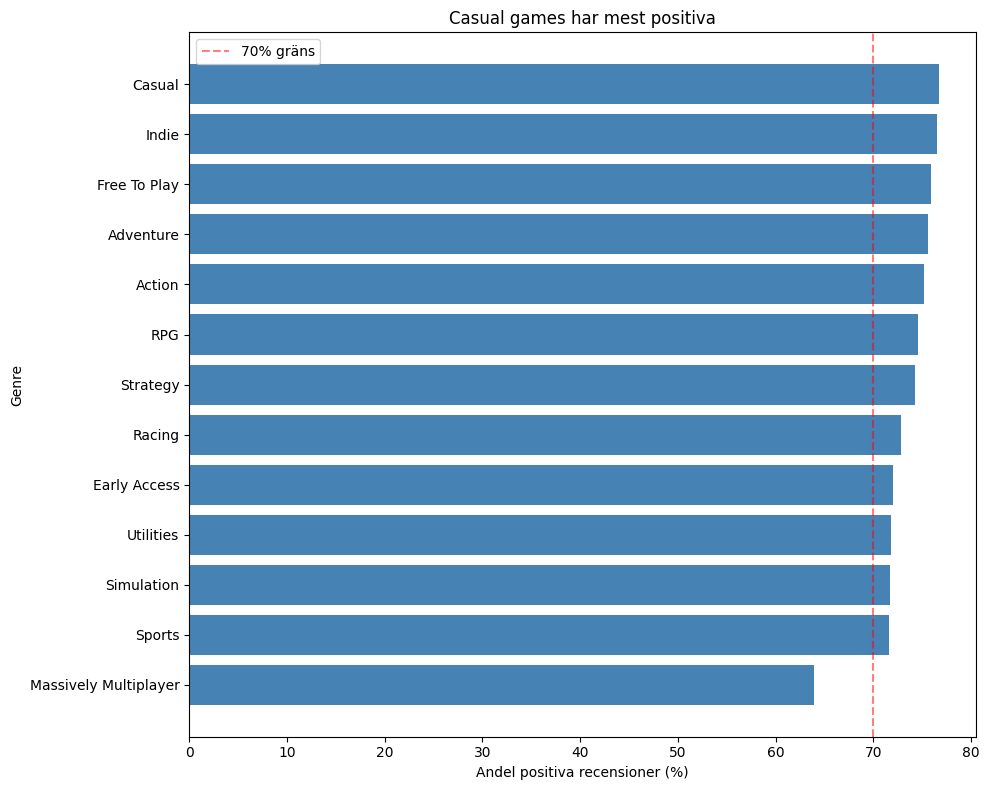

In [9]:
# Beräkna andel positiva recensioner per genre
df["Andel positiv"] = df["Positive"] / (df["Positive"] + df["Negative"])

# Genres är en sträng med kommaseparerade värden - splitta och explodera
genre_df = df.copy()
genre_df["Genres"] = genre_df["Genres"].str.split(",")
genre_df = genre_df.explode("Genres")
genre_df["Genres"] = genre_df["Genres"].str.strip()

# Beräkna medel per genre, bara genrer med fler än 500 spel
genre_betyg = genre_df.groupby("Genres").agg(
    andel=("Andel positiv", "mean"),
    antal=("Andel positiv", "count")
).reset_index()
genre_betyg = genre_betyg[genre_betyg["antal"] > 500].sort_values("andel")

# Rita diagrammet
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(genre_betyg["Genres"], genre_betyg["andel"] * 100, color="steelblue")

ax.set_xlabel("Andel positiva recensioner (%)")
ax.set_ylabel("Genre")
ax.set_title("Casual games har mest positiva")
ax.axvline(x=70, color="red", linestyle="--", alpha=0.5, label="70% gräns")
ax.legend()

plt.tight_layout()
plt.show()

Casual och Indie-spel har högst andel positiva recensioner bland alla genrer. 
Massively Multiplayer sticker ut negativt. det är troligtvis för att spelare är mer 
kritiska när de betalar månadsavgifter eller möter tekniska problem online.

### Fråga 2: Hur ser prisfördelningen ut bland Steam-spel?

Jag valde ett histogram eftersom vi vill se fördelningen av ett numeriskt värde (pris). 
Ett histogram visar hur många spel som kostar olika mycket, vilket är svårt att se i en tabell.

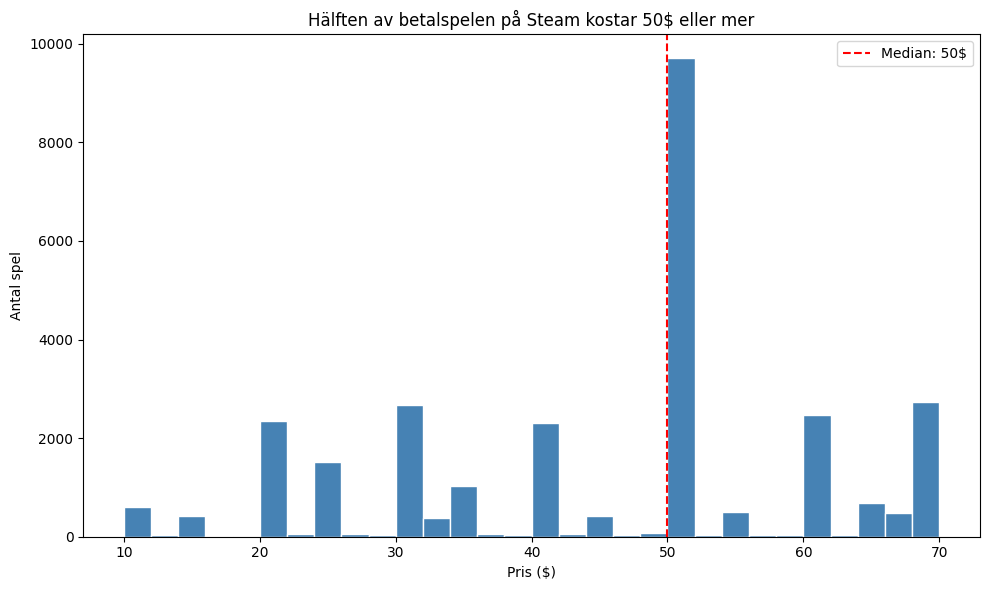

Andel gratispel: 64.4%
Median pris (betalspel): 50$


In [7]:
# Filtrera bort gratispel och extrema priser (över 70$)
df_betalt = df[(df["Price"] > 0) & (df["Price"] <= 70)]

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df_betalt["Price"], bins=30, color="steelblue", edgecolor="white")

ax.axvline(x=df_betalt["Price"].median(), color="red", linestyle="--",
           label=f'Median: {df_betalt["Price"].median():.0f}$')

ax.set_xlabel("Pris ($)")
ax.set_ylabel("Antal spel")
ax.set_title("Hälften av betalspelen på Steam kostar 50$ eller mer")
ax.legend()

plt.tight_layout()
plt.show()

print(f"Andel gratispel: {(df['Price'] == 0).sum() / len(df) * 100:.1f}%")
print(f"Median pris (betalspel): {df_betalt['Price'].median():.0f}$")

64% av alla Steam-spel är gratis. Bland betalspelen är medianen 50$ — 
det stora antalet spel vid just 50$ beror troligtvis på att många AAA-spel 
sätter standardpriset 49.99$. Spel under 20$ är vanliga indie-titlar.

### Fråga 3: Får dyrare spel bättre recensioner?

Jag valde ett scatter-diagram eftersom vi undersöker sambandet mellan två 
numeriska variabler (pris och betyg). En scatter visar om det finns ett 
mönster mellan dem.

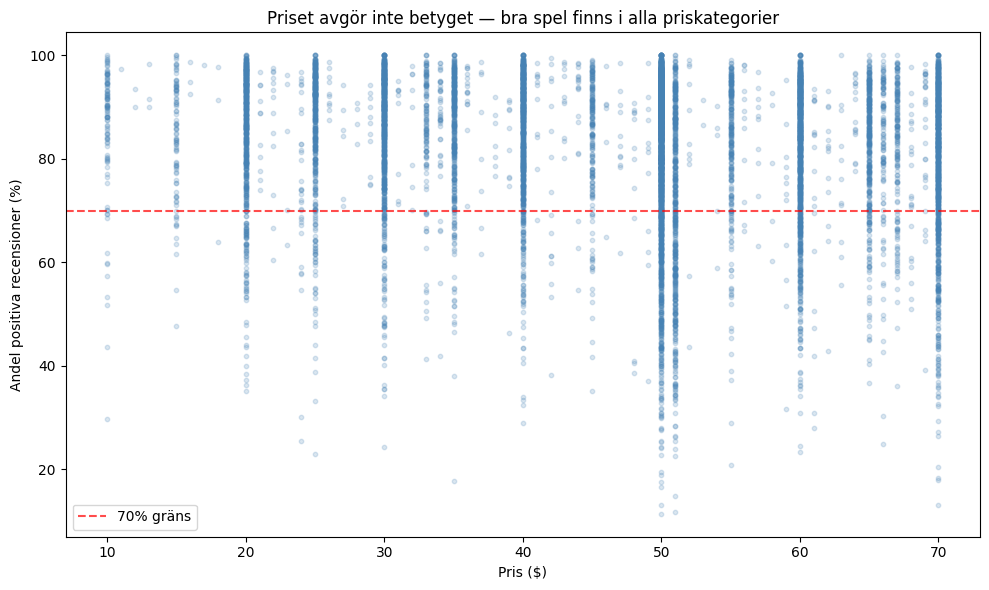

In [8]:
# Beräkna andel positiva om inte redan gjort
df["Andel positiv"] = df["Positive"] / (df["Positive"] + df["Negative"])

# Filtrera — bara spel med minst 50 recensioner och pris > 0
df_scatter = df[
    (df["Price"] > 0) & 
    (df["Price"] <= 70) & 
    ((df["Positive"] + df["Negative"]) >= 50)
]

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df_scatter["Price"], df_scatter["Andel positiv"] * 100,
           alpha=0.2, color="steelblue", s=10)

ax.axhline(y=70, color="red", linestyle="--", alpha=0.7, label="70% gräns")

ax.set_xlabel("Pris ($)")
ax.set_ylabel("Andel positiva recensioner (%)")
ax.set_title("Priset avgör inte betyget — bra spel finns i alla priskategorier")
ax.legend()

plt.tight_layout()
plt.show()

Scatter-diagrammet visar att det inte finns något tydligt samband mellan pris och betyg. 
Bra spel finns i alla priskategorier. De vertikala linjerna beror på att Steam 
använder standardpriser som 9.99$, 19.99$, 29.99$ — få spel har unika priser.

## 5. Avslutning — vad vi lärt oss och vad vi inte kan veta

**Mönster vi upptäckte:**
- Casual och Indie-spel har högst andel positiva recensioner
- 64% av alla Steam-spel är gratis
- Priset avgör inte betyget — bra spel finns i alla priskategorier

**Vad datan inte kan berätta:**
- Vi vet inte om spelen faktiskt är bra — bara att folk recenserade dem positivt
- Datasetet täcker inte spel som tagits bort från Steam
- Vi kan inte se om ett spel är ett indie-spel utan att det taggar sig självt som "Indie"